In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
borrowings = pd.read_csv("../../data/processed/library_borrowings.csv")
catalogue = pd.read_csv("../../data/processed/library_catalogue.csv")
inventory = pd.read_csv("../../data/processed/library_inventory.csv")

In [4]:
borrow_count_per_book = borrowings.groupby('Title').size().reset_index(name='borrow_count')
borrowings_with_count = borrowings.merge(borrow_count_per_book, on='Title')

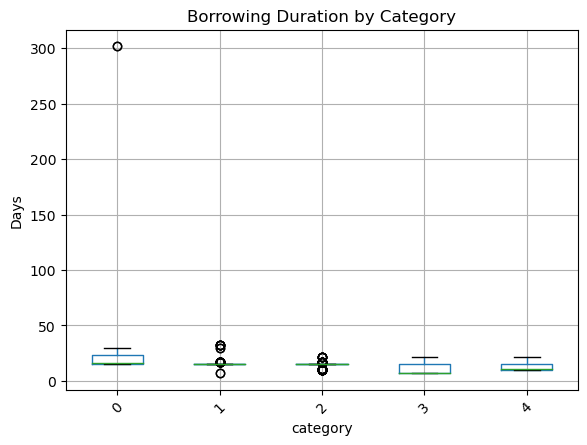

In [5]:
borrowings.boxplot(column='borrowing_duration', by='category', rot=45)
plt.title("Borrowing Duration by Category")
plt.suptitle("")
plt.ylabel("Days")
plt.show()

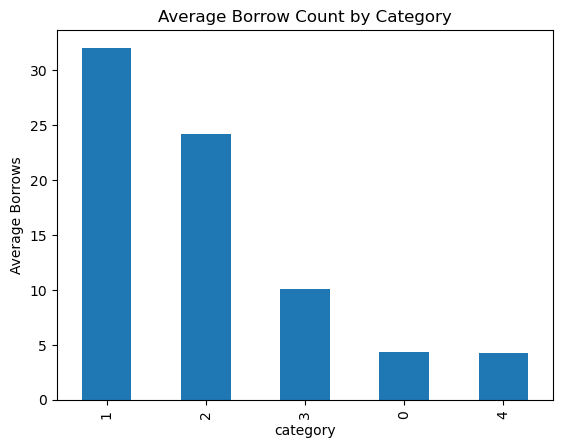

In [6]:
borrowings_with_count.groupby('category')['borrow_count'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Borrow Count by Category")
plt.ylabel("Average Borrows")
plt.show()

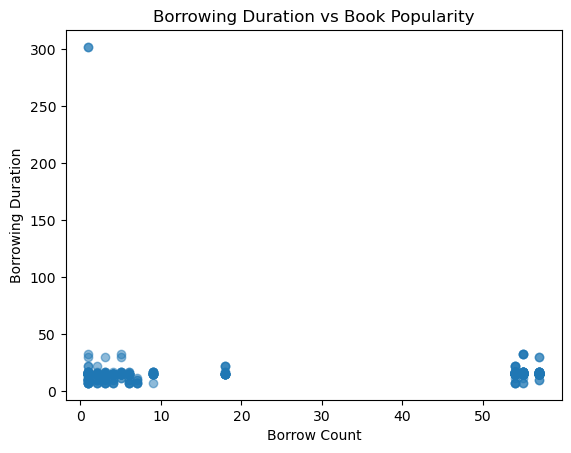

In [7]:
plt.scatter(
    borrowings_with_count['borrow_count'],
    borrowings_with_count['borrowing_duration'],
    alpha=0.5
)
plt.xlabel("Borrow Count")
plt.ylabel("Borrowing Duration")
plt.title("Borrowing Duration vs Book Popularity")
plt.show()


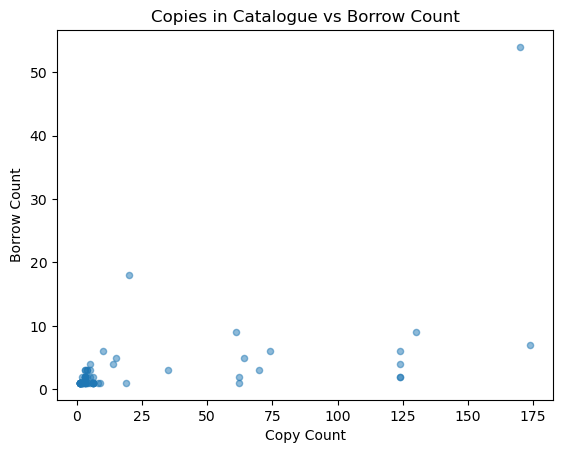

In [8]:
merged_catalogue = catalogue.merge(borrow_count_per_book, on='Title', how='left')
merged_catalogue.plot.scatter(x='Copy Count', y='borrow_count', alpha=0.5)
plt.title("Copies in Catalogue vs Borrow Count")
plt.xlabel("Copy Count")
plt.ylabel("Borrow Count")
plt.show()

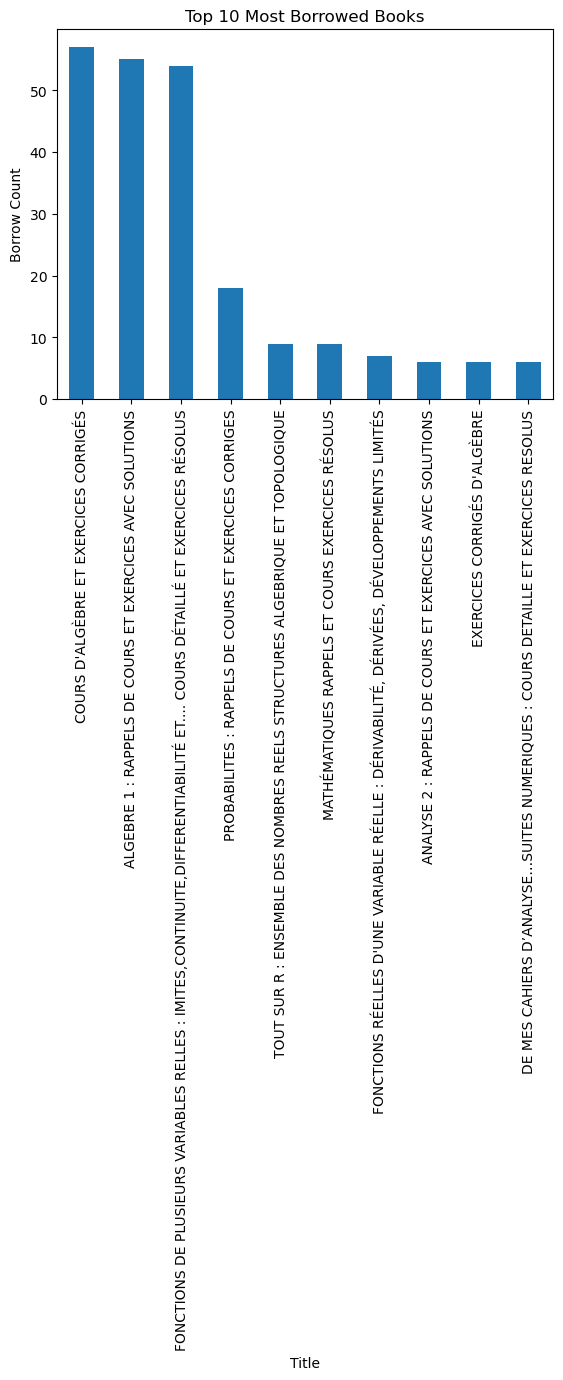

In [ ]:
borrowings['Title'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Borrowed Books")
plt.ylabel("Borrow Count")
plt.show()
